## Import CUDA

In [34]:
from numba import cuda

## Load the image

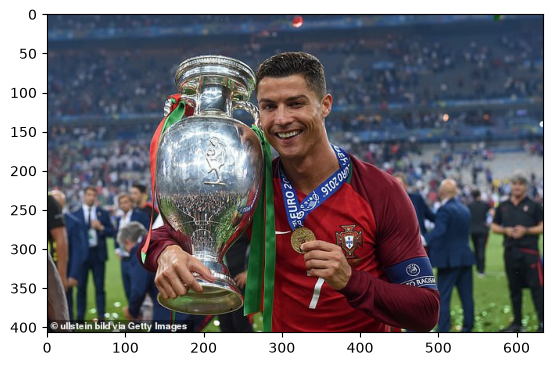

In [35]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

image = plt.imread('1.jpeg')

plt.imshow(image)

h, w, d = image.shape

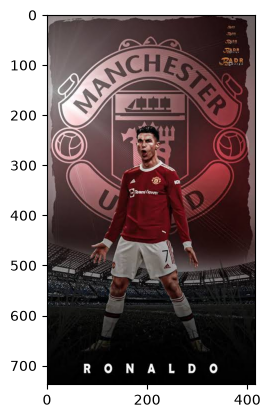

In [36]:
image_ronaldo = plt.imread('images.jpeg')
plt.imshow(image_ronaldo)

## Grayscale (map)

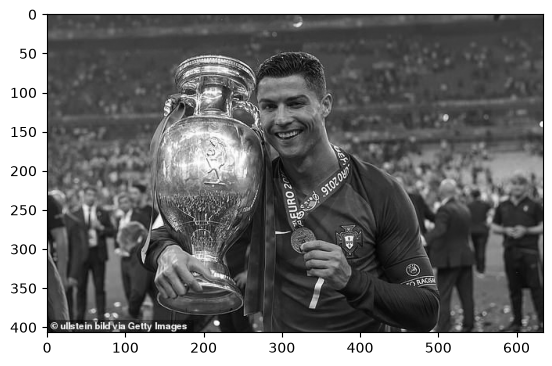

In [37]:
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return
    dst[tidy, tidx] = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)

blockSize = (32, 32)
gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
devSrc = cuda.to_device(image)
devGray = cuda.device_array((h, w), np.uint8)
grayscale[gridSize, blockSize](devSrc, devGray)
plt.imshow(devGray.copy_to_host(), cmap='gray')

## 6a: Binarization

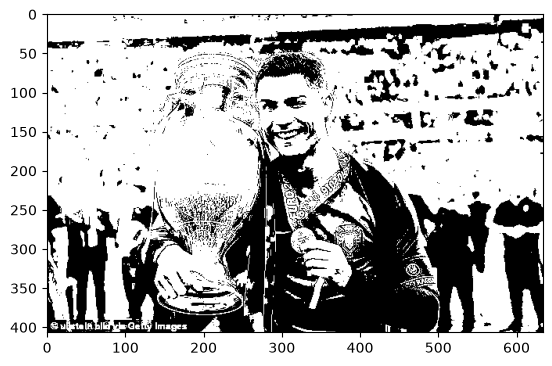

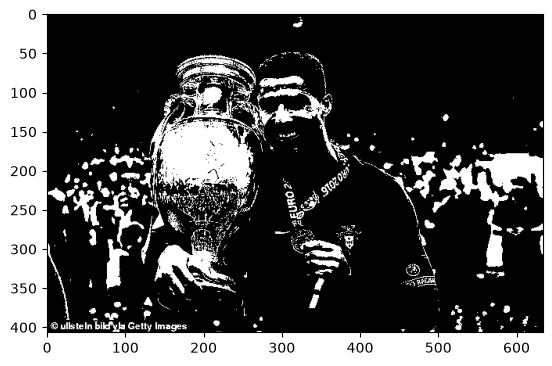

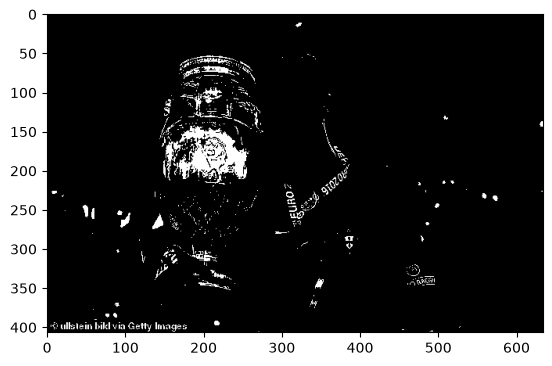

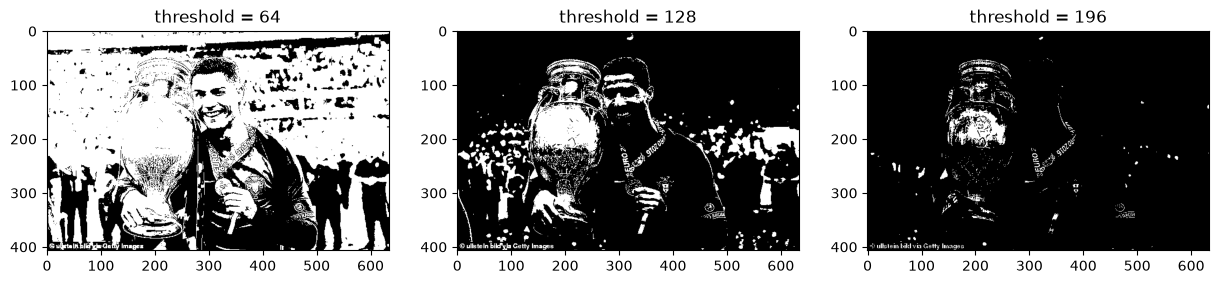

In [38]:
@cuda.jit
def binarize(src, dst, threshold):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return
    if src[tidy, tidx] < threshold:
        dst[tidy, tidx] = 0
    else:
        dst[tidy, tidx] = 1

devBin = cuda.device_array((h, w), np.uint8)
results = []
for threshold in [64, 128, 196]:
    binarize[gridSize, blockSize](devGray, devBin, threshold)
    plt.imshow(devBin.copy_to_host(), cmap='gray')
    plt.show()
    results.append(devBin.copy_to_host())

plt.figure(figsize=(15, 4))
for i, threshold in enumerate([64, 128, 196]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(results[i], cmap='gray')
    plt.title(f"threshold = {threshold}")
plt.show()

## 6b: Brightness control

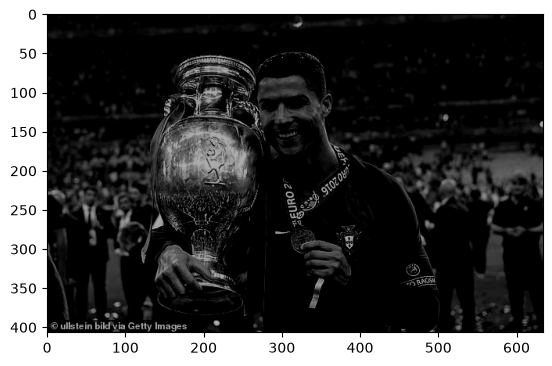

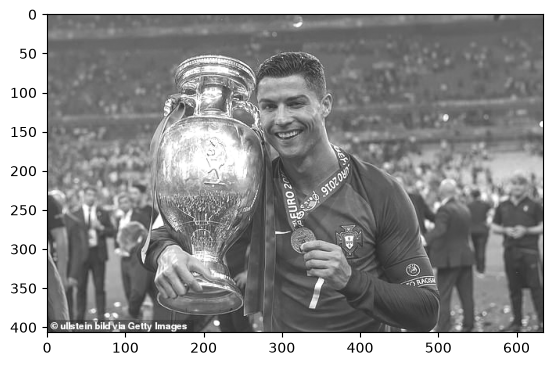

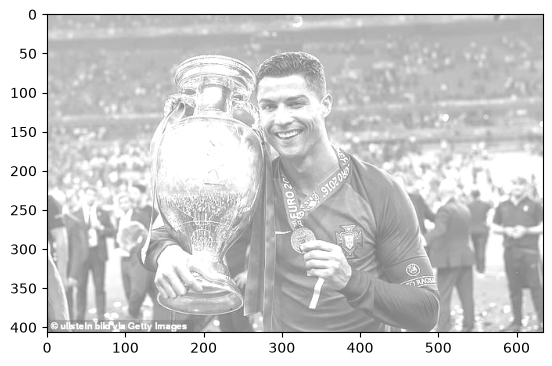

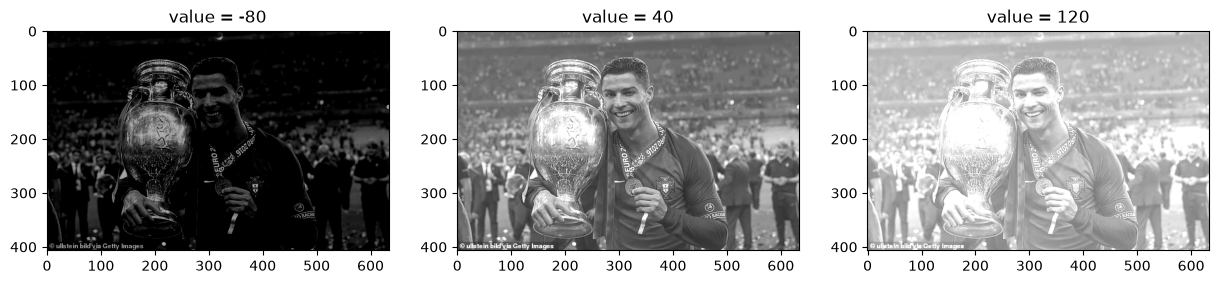

In [39]:
@cuda.jit
def brightness(src, dst, value):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return
    v = src[tidy, tidx] + value
    dst[tidy, tidx] = min(max(v, 0), 255)

devBright = cuda.device_array((h, w), np.uint8)
results = []
for value in [-80, 40, 120]:
    brightness[gridSize, blockSize](devGray, devBright, value)
    plt.imshow(devBright.copy_to_host(), cmap='gray', vmin=0, vmax=255)
    plt.show()
    results.append(devBright.copy_to_host())

plt.figure(figsize=(15, 4))
for i, value in enumerate([-80, 40, 120]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(results[i], cmap='gray', vmin=0, vmax=255)
    plt.title(f"value = {value}")
plt.show()

## Input images for blending

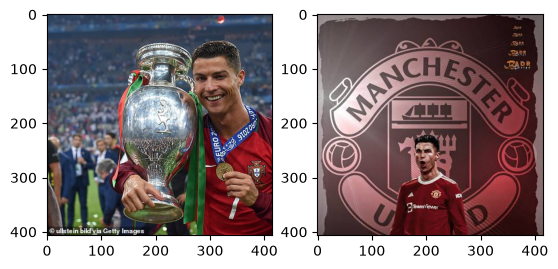

In [40]:
image2 = plt.imread('images.jpeg')
hb, wb = min(h, image2.shape[0]), min(w, image2.shape[1])
image1 = image[:hb, :wb].copy()
image2 = image2[:hb, :wb].copy()
plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.show()

## 6c: Blending two images

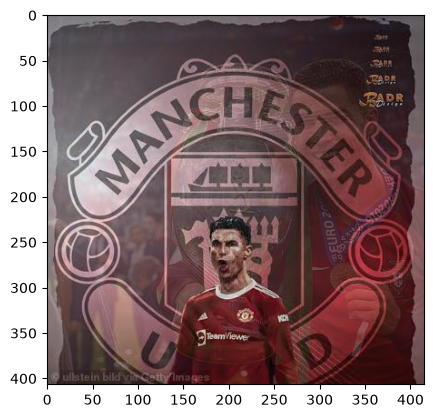

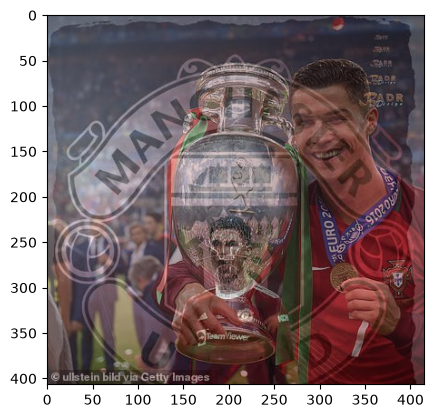

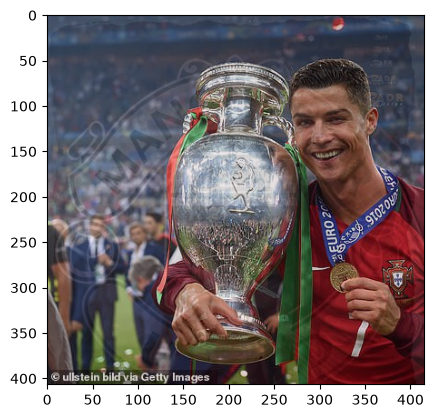

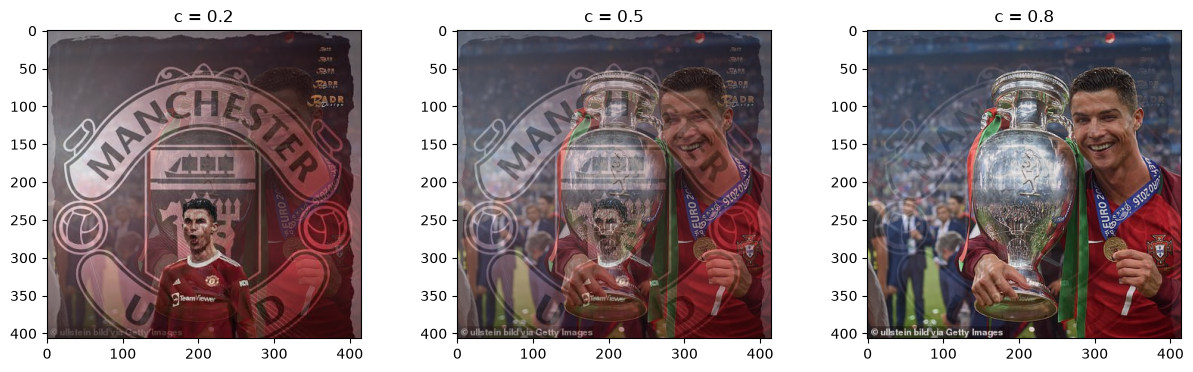

In [41]:
@cuda.jit
def blend(src1, src2, dst, c):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src1.shape[1] or tidy >= src1.shape[0]:
        return
    for k in range(3):
        dst[tidy, tidx, k] = c * src1[tidy, tidx, k] + (1 - c) * src2[tidy, tidx, k]

gridBlend = (math.ceil(wb / blockSize[0]), math.ceil(hb / blockSize[1]))
devSrc1 = cuda.to_device(image1)
devSrc2 = cuda.to_device(image2)
devBlend = cuda.device_array((hb, wb, 3), np.uint8)
results = []
for c in [0.2, 0.5, 0.8]:
    blend[gridBlend, blockSize](devSrc1, devSrc2, devBlend, c)
    plt.imshow(devBlend.copy_to_host())
    plt.show()
    results.append(devBlend.copy_to_host())

plt.figure(figsize=(15, 4))
for i, c in enumerate([0.2, 0.5, 0.8]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(results[i])
    plt.title(f"c = {c}")
plt.show()

## Block size vs time

Block size: (4, 4)
Grid size: (159, 102)
GPU time: 0.0006573200225830078, 0.0001571178436279297, 0.0002372264862060547 seconds
Block size: (8, 8)
Grid size: (80, 51)
GPU time: 0.00011086463928222656, 0.0001933574676513672, 0.0003108978271484375 seconds
Block size: (16, 16)
Grid size: (40, 26)
GPU time: 0.00013494491577148438, 0.00010633468627929688, 0.00016307830810546875 seconds
Block size: (32, 32)
Grid size: (20, 13)
GPU time: 8.296966552734375e-05, 0.00013589859008789062, 0.00013518333435058594 seconds


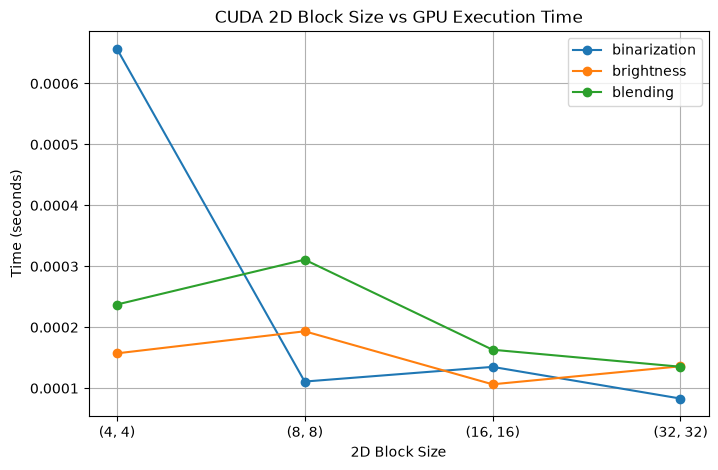

In [30]:
block_sizes = [(4, 4), (8, 8), (16, 16), (32, 32)]
times_bin = []
times_bright = []
times_blend = []

for blockSize in block_sizes:
    gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))

    start = time.time()
    binarize[gridSize, blockSize](devGray, devBin, threshold)
    cuda.synchronize()
    times_bin.append(time.time() - start)

    start = time.time()
    brightness[gridSize, blockSize](devGray, devBright, value)
    cuda.synchronize()
    times_bright.append(time.time() - start)

    start = time.time()
    gridBlend = (math.ceil(wb / blockSize[0]), math.ceil(hb / blockSize[1]))
    blend[gridBlend, blockSize](devSrc1, devSrc2, devBlend, c)
    cuda.synchronize()
    times_blend.append(time.time() - start)

    print(f"Block size: {blockSize}")
    print(f"Grid size: {gridSize}")
    print(f"GPU time: {times_bin[-1]}, {times_bright[-1]}, {times_blend[-1]} seconds")

plt.figure(figsize=(8, 5))
plt.plot([str(b) for b in block_sizes], times_bin, marker='o', label='binarization')
plt.plot([str(b) for b in block_sizes], times_bright, marker='o', label='brightness')
plt.plot([str(b) for b in block_sizes], times_blend, marker='o', label='blending')
plt.xlabel("2D Block Size")
plt.ylabel("Time (seconds)")
plt.title("CUDA 2D Block Size vs GPU Execution Time")
plt.legend()
plt.grid(True)
plt.show()